[README](README.md) | [Introduction](Introduction.md) | [Datasets](Datasets.md) | [Tasks](Tasks.md) | [Task 1](Task-1.md) | [Task 2](Task-2.md) | Notebook

# AS Centrality

In [1]:
name = "YOUR NAME HERE"
date = "MM/DD/YYYY"

In [2]:
%pip install -q requests pytricia pandas matplotlib pybgpkit-parser

import shutil
from pathlib import Path
from collections import defaultdict, Counter

import requests
import pytricia
import pandas as pd
import matplotlib.pyplot as plt
import pybgpkit_parser as bgpkit

Note: you may need to restart the kernel to use updated packages.


## Pre-task: Obtain BGP and ASN data

### Pre-task 1: Download BGP data

In the [BGP assignment](https://github.com/CAIDA/nids-bgp-control-plane), you fetched BGP Routing Information Base (RIB) snapshots from a *single* collector managed by [RouteViews](https://www.routeviews.org/routeviews/). This time, you will fetch the same type of data from *multiple* collectors, managed by [RIPE RIS](https://www.ripe.net/analyse/internet-measurements/routing-information-service-ris/). 

Using data from more collectors requires significantly more computing power. When first writing your code, you should use `COLLECTORS = ["rrc06"]` so that the notebook executes more quickly. When answering the questions for the tasks, use the larger set of data with `COLLECTORS = ["rrc00", "rrc15", "rrc23"]`.

| Collector | Location | File size (compressed) |
|-----------|----------|------------------------|
| `rrc00`   | Amsterdam, NL | ~400 MB |
| `rrc06`   | Otemachi, JP  | ~40 MB  |
| `rrc15`   | São Paolo, BR | ~135 MB |
| `rrc23`   | Singapore, SG | ~80 MB  |

In [3]:
# COLLECTORS = ["rrc06"]                      # Uncomment for testing (41 MB)
COLLECTORS = ["rrc00", "rrc15", "rrc23"]      # Uncomment for full analysis
SNAPSHOT_DATE = "20260801"                    # YYYYMMDD
SNAPSHOT_HOUR = "0000"                        # 0000, 0800, 1600 UTC

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

def fetch_rib_file(collector, date=None, hour=None):
    """
    Download a RIB file into data directory if not already cached;
    Return file path.
    """
    date = date or SNAPSHOT_DATE
    hour = hour or SNAPSHOT_HOUR
    fname = f"bview.{collector}.{date}.{hour}.gz"
    fpath = DATA_DIR / f"{fname}"
    if fpath.exists():
        print(f"Found in cache: {fname}")
        return fpath
    
    fpath.parent.mkdir(parents=True, exist_ok=True)
    download_url = (
        f"https://data.ris.ripe.net/"
        f"{collector}/{date[:4]}.{date[4:6]}/bview.{date}.{hour}.gz"
    )
    with requests.get(download_url, stream=True) as resp:
        resp.raise_for_status()
        with open(fpath, "wb") as fout:
            shutil.copyfileobj(resp.raw, fout)
    print(f"Downloaded: {fname}")
    return fpath

RIB_PATHS = [ fetch_rib_file(c) for c in COLLECTORS ]
print("Fetched all RIB files.")

Found in cache: bview.rrc00.20260801.0000.gz
Found in cache: bview.rrc15.20260801.0000.gz
Found in cache: bview.rrc23.20260801.0000.gz
Fetched all RIB files.


### Pre-task 2: Download and parse AS Names data

Raw BGP data identifies ASes only by their ASN. To make the data more comprehensible, you will map each ASN to its organization name and country using **[RIPE NCC's AS Names dataset](https://ftp.ripe.net/ripe/asnames/)**.

In [4]:
ASNAMES_URL = "https://ftp.ripe.net/ripe/asnames/asn.txt"
fname = "asnames.txt"
fpath = DATA_DIR / f"{fname}"

if not fpath.exists():
    with requests.get(ASNAMES_URL, stream=True) as resp:
        resp.raise_for_status()
        with open(fpath, "w", encoding="utf-8") as fout:
            fout.write(resp.text)
    print(f"Downloaded: {fname}")

try:
    data = {}
    with open(fpath, "r", encoding="utf-8") as fin:
        for line in fin:
            asn, _ , rest = line.strip().partition(" ")
            name, _ , country = rest.rpartition(", ")
            data[asn] = {"name": name, "country": country}
except Exception as e:
    print(f"An error occurred: {e}")

as_info_df = pd.DataFrame.from_dict(data, orient='index', columns=['name','country'])
as_info_df.head(10)

,name,country
1,"LVLT-1 - Level 3 Parent, LLC",US
2,UDEL-DCN - University of Delaware,US
3,MIT-GATEWAYS - Massachusetts Institute of Tech...,US
4,ISI-AS - University of Southern California,US
5,SYMBOLICS - WFA Group LLC,US
6,"BULL-HN - ATOS IT Solutions and Services, Inc.",US
7,DSTL - The Defence Science and Technology Labo...,EU
8,RICE-AS - Rice University,US
9,CMU-ROUTER - Carnegie Mellon University,US
10,CSNET-EXT-AS - CSNET Coordination and Informat...,US


## Task 1: Process BGP data

You should read the [dataset documentation](Datasets.md) to better understand how BGP
data is structured and how BGPKIT works.

### Task 1.1: Extract data from RIB files

You will use **[BGPKIT](https://bgpkit.com/)** to parse the RIB snapshots you just 
downloaded. Instead of handling compressed binary files directly, it lets you iterate
over each entry as a Python object. This process could take up to 10 minutes for the
full dataset. 

As you go through the entries, you will:
1. **Store each announced prefix in a radix tree** so you can look up which prefixes 
are contained within others. 
2. **Build a view for each peer** by collecting every AS path observed by that peer.
3. **Keep track of every ASN and peer** that shows up in the data.
4. **Track all unique AS paths across the entire dataset**, since the same AS path
may be observed by multiple peers.

In [ ]:
def parse_rib_data(RIB_PATHS):
    """
    Each element returned by bgpkit parser represents a RIB table entry with the
    following format. For example:
    {
        'elem_type': 'R', 
        'peer_asn': 1234,
        'peer_address': '80.77.16.114',
        'as-path': '1234 956 14068',
        'origin': 14068,
        'prefix': '216.163.136.0/24'
    }
    
    We define 'full_path' as an AS path from peer's ASN to origin ASN. 
    We define 'atom' as an AS path excluding its origin AS.
        - Using 'atom' is mainly for reducing memory use:
            For example, when there are the paths:
            A -> B -> C -> origin_X
            A -> B -> C -> origin_Y
            A -> B -> C -> origin_Z
            Instead of storing them as three distinct path, we can instead do: 
            {
                key : (A -> B -> C),
                values: [origin_X, origin_Y, origin_Z]
            }
            This way, the intermediate path is only stored once. When there is
            a large amount of data, this saves a lot of memory.
    
    @ pyt: Radix tree for prefix weighing
    @ local_views: Map a peer to every AS path that it sees
    @ all_peer: Set of every peer that appear in the data. 
    @ all_asn: Set of every ASN that appear in the data. 
    @ unique_paths: Map an AS path to every prefix announced in its origin prefix. 
    """
    pyt = pytricia.PyTricia(32)
    local_views = defaultdict(lambda: defaultdict(set))
    all_peer = set()
    all_asn = set()
    unique_paths = defaultdict(set)
    n_processed = 0

    for p in RIB_PATHS:
        for element in bgpkit.Parser(url=str(p)):
            # process route announcements only
            if element.elem_type != "A":
                continue

            # skip v6 and default routes
            o_pfx = element.prefix
            if ":" in o_pfx or o_pfx.endswith("/0"):
                continue
            
            # >>> STUDENT CODE START >>>
            # Hints:
            # Add the announced prefix to the radix tree 'pyt'. 
            # Break the full AS path into 'atom' and origin ASN. 
            # Add this path to the peer's view in 'local_views'. 
            # Track this peer and all ASNs that were seen. 
            # Store this AS path as a unique path, along with its prefixes. 

            pyt.insert(o_pfx, None)

            full_path = element.as_path.split(" ")
            atom, o_asn = tuple(full_path[:-1]), full_path[0]

            peer_ip = element.peer_ip
            local_views[peer_ip][atom].add((o_asn, o_pfx))
            all_peer.add(peer_ip)
            for asn in full_path:
                all_asn.add(asn)
            
            unique_paths[(atom, o_asn)].add(o_pfx)
            
            # <<< STUDENT CODE END <<<

            n_processed += 1
            if n_processed % 5_000_000 == 0: 
                print(f"...Processed {n_processed:,} entries")
                
    print(f"\nProcessed {n_processed:,} RIB entries across {len(RIB_PATHS):,} snapshot(s).")
    return pyt, dict(local_views), all_peer, all_asn, unique_paths

### Task 1.2: Compute address space size

In [ ]:
def get_address_count(pfx):
    pfx_len = 32 - int(pfx.split("/")[1])
    return 1 << pfx_len
    
def weigh_prefixes(pyt):
    """
    Assign weights to each observed prefix by the size of its address space.
    No double counting (see task description). 
    """
    pfx_to_weight = {}
    
    # >>> STUDENT CODE START >>>
    # Hints:
    # Calculate the address-space size of each prefix.
    # Find the direct children of each prefix and subtract their address space.
    # Store the prefix's resulting weight in 'pfx_to_weight'. 
    
    for pfx in pyt:
        pfx_weight = get_address_count(pfx)
        children_weight = 0
        for child in pyt.children(pfx):
            if pyt.parent(child) == pfx:
                children_weight += get_address_count(child)
        pfx_to_weight[pfx] = pfx_weight - children_weight
        
    # <<< STUDENT CODE END <<<

    return pfx_to_weight

In [7]:
pyt, local_views, all_peer, all_asn, unique_paths = parse_rib_data(RIB_PATHS)
pfx_to_weight = weigh_prefixes(pyt)

n_prefix = len(pfx_to_weight)
observed_addrs = sum(pfx_to_weight.values())

print(f"Observed {len(all_asn):,} ASNs.")
print(f"Observed IPv4 address space: {observed_addrs:,} addresses "
      f"by {len(all_peer):,} peers from collector(s): {', '.join(COLLECTORS)}.")
print(f"Weighted {n_prefix:,} prefixes.")

...Processed 5,000,000 entries
...Processed 10,000,000 entries
...Processed 15,000,000 entries
...Processed 20,000,000 entries
...Processed 25,000,000 entries
...Processed 30,000,000 entries
...Processed 35,000,000 entries
...Processed 40,000,000 entries
...Processed 45,000,000 entries
...Processed 50,000,000 entries
...Processed 55,000,000 entries
...Processed 60,000,000 entries
...Processed 65,000,000 entries
...Processed 70,000,000 entries

Processed 70,168,671 RIB entries across 3 snapshot(s).
Observed 79,988 ASNs.
Observed IPv4 address space: 3,129,899,221 addresses by 127 peers from collector(s): rrc00, rrc15, rrc23.
Weighted 1,168,495 prefixes.


## Task 2: Compute betweenness centrality

### Task 2.1: Compute BC score for every ASN

In [8]:
def compute_bc_scores(unique_paths, pfx_to_weight, all_asn):
    """
    Compute betweenness centrality (BC) for every ASN. 
    """
    bc_scores = defaultdict(lambda: {"uw" : 0.0, "w" : 0.0})
    total_observed_path_uw = len(unique_paths)
    total_observed_path_w = sum(
        pfx_to_weight[o_pfx]
        for o_pfxs in unique_paths.values()
            for o_pfx in o_pfxs
    )
    path_with_asn_uw = defaultdict(int)
    path_with_asn_w = defaultdict(float)

    # >>> STUDENT CODE START >>>
    # Hints:
    # For unweighted BC:
    # BC(X) = (count of observed paths containing X) / (count of all observed paths)
    # For weighted BC:
    # We weigh each path by its origin prefix's address space size, so:
    # BC(X) = (weights of observed paths containing X) / (weight of all observed paths)
    
    for (atom, o_asn), o_pfxs in unique_paths.items():
        full_path = set(atom)
        full_path.add(o_asn)

        weight = sum(pfx_to_weight[o_pfx] for o_pfx in o_pfxs)
        for asn in full_path:
            path_with_asn_uw[asn] += 1
            path_with_asn_w[asn] += weight

    for asn in all_asn:
        bc_scores[asn] = {
            "uw": path_with_asn_uw[asn] / total_observed_path_uw,
            "w": path_with_asn_w[asn] / total_observed_path_w,
        }
        
    # <<< STUDENT CODE END <<<
    
    return bc_scores

bc_scores = compute_bc_scores(unique_paths, pfx_to_weight, all_asn)

### Task 2.2: Summarize BC data

In [9]:
bc_df = pd.DataFrame.from_dict(bc_scores, orient="index")

bc_df_enriched = (
    bc_df
    .merge(as_info_df, left_index=True, right_index=True)
    .reset_index(names="asn")
    .assign(
        uw_rank=lambda df: df['uw'].rank(ascending=False).astype(int),
        w_rank=lambda df: df['w'].rank(ascending=False).astype(int)
    )
    .reindex(columns=["w_rank","uw_rank","asn","name","country","uw","w"])
    .sort_values("w", ascending=False)
    .reset_index(drop=True)
)

bc_df_enriched.head(15)

,w_rank,uw_rank,asn,name,country,uw,w
0,1,2,3356,"LEVEL3 - Level 3 Parent, LLC",US,0.152262,0.238074
1,2,4,1299,TWELVE99 Arelion Sweden AB,SE,0.129935,0.175508
2,3,1,6939,HURRICANE - Hurricane Electric LLC,US,0.198662,0.132875
3,4,3,174,"COGENT-174 - Cogent Communications, LLC",US,0.131958,0.132267
4,5,5,2914,"NTT-DATA-2914 - NTT America, Inc.",US,0.063745,0.082275
5,6,6,58057,SECUREBIT Securebit AG,CH,0.055296,0.058192
6,7,7,9002,RETN-AS RETN Limited,GB,0.054501,0.051819
7,8,10,34549,MEER-AS meerfarbig GmbH & Co. KG,DE,0.044450,0.048198
8,9,8,3257,GTT-BACKBONE GTT Communications Inc.,US,0.047005,0.043121
9,10,9,6762,SEABONE-NET TELECOM ITALIA SPARKLE S.p.A.,IT,0.044852,0.041361


**Q1**: *What does betweenness centrality measure?*

It measures the likelihood of an AS to lie on observed AS paths. An AS with a high BC
shows up on many paths, so it is likely playing a role as a transit AS. An AS with a
low BC shows up on fewer paths and is more likely to be a stub AS. 

**Q2**: *Why would we use the weighted betweenness centrality versus the unweighted*
*betweenness centrality?*

Unweighted BC treats every AS path equally, which disregards how much address space 
the path leads to. Weighted BC gives more weight to paths that route to origins with
larger prefixes. This lets us see which ASes are important not just across paths, but
across paths with different levels of importance.

### Task 2.3: Distribution of betweenness centrality across ASes

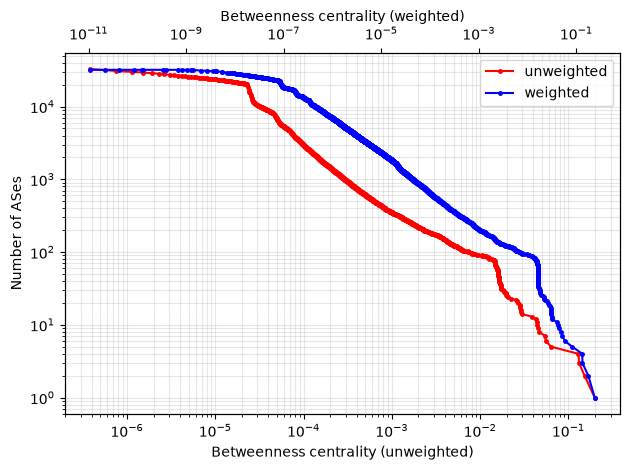

In [10]:
"""
CCDF for unweighted betweenness centrality.
For each BC value x, count how many ASes have BC >= x,
"""
# >>> STUDENT CODE START >>>

bc_uw_list = [v for v in bc_df_enriched["uw"] if v > 0]
bc_uw_dist = Counter(bc_uw_list)
x_bc_uw = sorted(bc_uw_dist.keys())
y_bc_uw = []
remaining = len(bc_uw_list) 
for xi in x_bc_uw:
    y_bc_uw.append(remaining)
    remaining -= bc_uw_dist[xi]

# <<< STUDENT CODE END <<<

"""
CCDF for weighted betweenness centrality.
Same computation, but for weighted betweenness centrality.
"""
# >>> STUDENT CODE START >>>

bc_w_list = [v for v in bc_df_enriched["w"] if v > 0]
bc_w_dist = Counter(bc_w_list)
x_bc_w = sorted(bc_w_dist.keys())
y_bc_w = []
remaining = len(bc_w_list)
for xi in x_bc_w:
    y_bc_w.append(remaining)
    remaining -= bc_w_dist[xi]
    
# <<< STUDENT CODE END <<<

fig, ax1 = plt.subplots()
ax1.plot(x_bc_uw, y_bc_uw, marker=".", markersize=5, color="red", label="unweighted")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("Betweenness centrality (unweighted)")
ax1.set_ylabel("Number of ASes")

ax2 = ax1.twiny()
ax2.plot(x_bc_w, y_bc_w, marker=".", markersize=5, color="blue", label="weighted")
ax2.set_xscale("log")
ax2.set_xlabel("Betweenness centrality (weighted)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
ax1.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

**Q3**: *What shape does the CCDF have? What does this tell us about the distribution*
*of weighted betweenness centralities?*

The CCDF has a long-tailed shape, with most ASes having relatively low BC and a small
number of ASes having much higher BC. This means that weighted betweenness centrality
is concentrated among a small number of ASes. This is consistent with the distribution
of AS customer cone size, where a small number of transit ASes have wide reach, while
a large number of eyeball ASes have much more limited reach.

## Task 3: Compute hegemony

In [11]:
def _bc_for_every_asn_per_peer(one_peer_view, pfx_to_weight):
    """
    Compute one peer's local BC score for every ASN that it observes.
    """
    peer_scores = {}
    total_observed_path_uw = 0
    total_observed_path_w = 0.0
    path_with_asn_uw = defaultdict(int)
    path_with_asn_w = defaultdict(float)

    # >>> STUDENT CODE START >>>
    # Hints:
    # Iterate through each observed path and its origin/prefix pairs.
    # Count each observed path and accumulate its prefix weight.
    # For each ASN in the path, track its path count and accumulated path weight.
    # Calculate each ASN's unweighted and weighted BC scores.

    for atom, o_asn_pfx_pairs in one_peer_view.items():
        for o_asn, o_pfx in o_asn_pfx_pairs:
            weight = pfx_to_weight[o_pfx]
            total_observed_path_uw += 1
            total_observed_path_w += weight

            full_path = set(atom)
            full_path.add(o_asn)

            for asn in full_path:
                path_with_asn_uw[asn] += 1
                path_with_asn_w[asn] += weight
            
    for asn in path_with_asn_uw:
        peer_scores[asn] = (
            path_with_asn_uw[asn] / total_observed_path_uw,
            path_with_asn_w[asn] / total_observed_path_w,
        )
        
    # <<< STUDENT CODE END <<<

    return peer_scores


In [12]:
def compute_hegemony_scores(local_views, pfx_to_weight, all_asn, all_peer):
    """
    Compute hegemony for every ASN.
    """
    hege_scores = defaultdict(lambda: {"uw":0.0, "w":0.0})
    peer_scores = {}
    ALPHA = 0.1
    # >>> STUDENT CODE START >>>
    # Hints:
    # Determine how many peer BC scores should be dropped from each end
    n_drop = int(len(all_peer) * ALPHA)
    # <<< STUDENT CODE END <<<

    for peer, one_peer_view in local_views.items():
        peer_scores[peer] = _bc_for_every_asn_per_peer(one_peer_view, pfx_to_weight)

    for target_asn in all_asn:
        bc_score_lst_uw = []
        bc_score_lst_w = []

        for peer in all_peer:

            # >>> STUDENT CODE START >>>
            # For each peer, retrieve the BC score for 'target_asn'
            # If the peer does not observe 'target_asn', use a BC score of zero
            # Add the unweighted and weighted scores to their respective lists

            if peer in peer_scores and target_asn in peer_scores[peer]:
                bc_uw, bc_w = peer_scores[peer][target_asn]
            else:
                bc_uw, bc_w = 0.0, 0.0
            bc_score_lst_uw.append(bc_uw)
            bc_score_lst_w.append(bc_w)

            # <<< STUDENT CODE END <<<

        # >>> STUDENT CODE START >>>
        # Hints:
        # Sort the BC scores so the most biased ones can be removed
        # Average the remaining scores to compute the unweighted and weighted hegemony. 
        
        bc_score_lst_uw.sort()
        bc_score_lst_w.sort()

        if n_drop > 0:
            bc_score_lst_uw = bc_score_lst_uw[n_drop:-n_drop]
            bc_score_lst_w = bc_score_lst_w[n_drop:-n_drop]
        
        hege_scores[target_asn]["uw"] = (
            sum(bc_score_lst_uw) / len(bc_score_lst_uw)
        )
        hege_scores[target_asn]["w"] = (
            sum(bc_score_lst_w) / len(bc_score_lst_w)
        )
        
        # <<< STUDENT CODE END <<<

    return dict(hege_scores)

hege = compute_hegemony_scores(local_views, pfx_to_weight, all_asn, all_peer)

### Task 3.2: Summarize hegemony data

In [13]:
hege_df = pd.DataFrame.from_dict(hege, orient="index")

hege_df_enriched = (
    hege_df
    .merge(as_info_df, left_index=True, right_index=True)
    .reset_index(names="asn")
    .assign(
        uw_rank=lambda df: df["uw"].rank(ascending=False).astype(int),
        w_rank=lambda df: df["w"].rank(ascending=False).astype(int)
    )
    .reindex(columns=["w_rank","uw_rank","asn","name","country","uw","w"])
    .sort_values("w", ascending=False)
    .reset_index(drop=True)
)
hege_df_enriched.head(15)

,w_rank,uw_rank,asn,name,country,uw,w
0,1,2,3356,"LEVEL3 - Level 3 Parent, LLC",US,0.054297,0.088243
1,2,1,6939,HURRICANE - Hurricane Electric LLC,US,0.059063,0.037622
2,3,3,1299,TWELVE99 Arelion Sweden AB,SE,0.039806,0.037494
3,4,4,174,"COGENT-174 - Cogent Communications, LLC",US,0.035696,0.024723
4,5,34,16509,"AMAZON-02 - Amazon.com, Inc.",US,0.002748,0.020080
5,6,5,2914,"NTT-DATA-2914 - NTT America, Inc.",US,0.019521,0.016438
6,7,15,721,DNIC-ASBLK-00721-00726 - United States Departm...,US,0.006063,0.011427
7,8,10,6762,SEABONE-NET TELECOM ITALIA SPARKLE S.p.A.,IT,0.010760,0.009452
8,9,14,12956,TELXIUS TELEFONICA GLOBAL SOLUTIONS SL,ES,0.006478,0.008538
9,10,26,701,UUNET - Verizon Business,US,0.003439,0.008130


**Q1**: *Why do we remove the top and bottom $\alpha$ proportions of the viewpoints?*

We remove the top and bottom $\alpha$ to reduce the effect of biased viewpoints. 
Some peers may see an AS much more or less frequently than others because of where 
they are located in the network.

**Q2**: *How do the top 5 ASes ranked by betweenness centrality compare to the top 5*
*ranked by AS hegemony?*

The top ASes are fairly consistent across the two metrics. Level 3, Hurricane,
Arelion, and Cogent are all ranked near the top in both weighted and unweighted BC.
The biggest difference is that if Amazon, which ranks 5th in weighted BC but only
34th in unweighted BC. This could be because Amazon announces a relatively small
number of prefixes, but those prefixes cover a large amount of address space.
As a result, Amazon's importance increases substantially when the paths are weighted
by the address space they lead to.

### Task 3.3: Compare BC and hegemony data

In [14]:
compare_df = (
    hege_df
    .merge(bc_df, left_index=True, right_index=True, suffixes=("_hege", "_bc"))
    .merge(as_info_df, left_index=True, right_index=True)
    .reset_index(names="asn")
    .assign(
        uw_hege_rank=lambda df: df["uw_hege"].rank(ascending=False).astype(int),
        w_hege_rank=lambda df: df["w_hege"].rank(ascending=False).astype(int),
        uw_bc_rank=lambda df: df["uw_bc"].rank(ascending=False).astype(int),
        w_bc_rank=lambda df: df["w_bc"].rank(ascending=False).astype(int),
    )
    .reindex(columns=[
        "asn","name","country",
        "uw_hege","w_hege",
        "uw_bc","w_bc",
        "uw_hege_rank","w_hege_rank",
        "uw_bc_rank","w_bc_rank"
    ])
    .sort_values("w_hege_rank", ascending=True)
    .reset_index(drop=True)
)

rank_df = (
    compare_df[[
        "w_hege_rank","w_bc_rank",
        "asn","name","country",
        "w_hege", "w_bc"
    ]]
)
rank_df.head(15)

,w_hege_rank,w_bc_rank,asn,name,country,w_hege,w_bc
0,1,1,3356,"LEVEL3 - Level 3 Parent, LLC",US,0.088243,0.238074
1,2,3,6939,HURRICANE - Hurricane Electric LLC,US,0.037622,0.132875
2,3,2,1299,TWELVE99 Arelion Sweden AB,SE,0.037494,0.175508
3,4,4,174,"COGENT-174 - Cogent Communications, LLC",US,0.024723,0.132267
4,5,11,16509,"AMAZON-02 - Amazon.com, Inc.",US,0.020080,0.039216
5,6,5,2914,"NTT-DATA-2914 - NTT America, Inc.",US,0.016438,0.082275
6,7,23,721,DNIC-ASBLK-00721-00726 - United States Departm...,US,0.011427,0.022058
7,8,10,6762,SEABONE-NET TELECOM ITALIA SPARKLE S.p.A.,IT,0.009452,0.041361
8,9,20,12956,TELXIUS TELEFONICA GLOBAL SOLUTIONS SL,ES,0.008538,0.026139
9,10,24,701,UUNET - Verizon Business,US,0.008130,0.021537


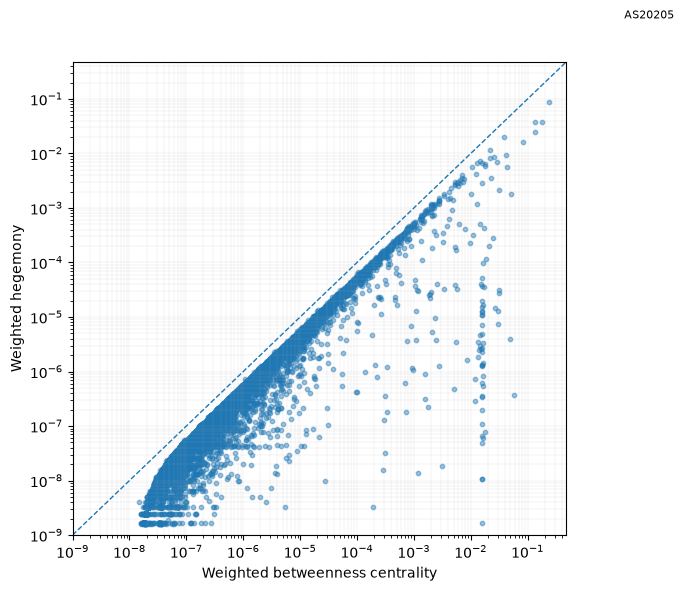

In [15]:
pos = compare_df[(compare_df["w_bc"] > 0) & (compare_df["w_hege"] > 0)]
pos["bc_hege_ratio"] = pos["w_bc"] / pos["w_hege"]

fig, ax = plt.subplots(figsize=(7, 6))

lo = max(min(pos["w_bc"].min(), pos["w_hege"].min()), 1e-9)
hi = max(pos["w_bc"].max(), pos["w_hege"].max()) * 2
ax.plot([lo, hi], [lo, hi], linewidth=1, linestyle="--")

ax.scatter(pos["w_bc"], pos["w_hege"], s=10, alpha=0.45)

asn_outlier = pos.iloc[(pos["w_bc"] / pos["w_hege"]).argmax()]
ax.annotate(f"AS{asn_outlier['asn']}", xy=(asn_outlier["w_bc"], asn_outlier["w_hege"]),
            xytext=(5, 3), fontsize=8)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.grid(True, which="major", linewidth=0.2, alpha=0.5)
ax.grid(True, which="minor", linewidth=0.2, alpha=0.5)
ax.set_xlabel("Weighted betweenness centrality")
ax.set_ylabel("Weighted hegemony")
fig.tight_layout()
plt.show()

In [16]:
N_OUTLIER = 10
outliers = pos.nlargest(N_OUTLIER, "bc_hege_ratio")

for _, row in outliers.iterrows():
    ax.annotate(
        f"AS{row['asn']}",
        xy=(row["w_bc"], row["w_hege"]),
    )

outlier_df = (
    outliers[
        [
            "asn", "name", "country",
            "w_hege", "w_bc",
            "w_hege_rank", "w_bc_rank",
            "bc_hege_ratio"
        ]
    ]
    .sort_values("bc_hege_ratio", ascending=False)
    .reset_index(drop=True)
)
display(outlier_df)

,asn,name,country,w_hege,w_bc,w_hege_rank,w_bc_rank,bc_hege_ratio
0,20205,"AMPLEX - Amplex Electric, Inc.",US,1.634698e-09,0.016091,24744,43,9.843603e+06
1,49134,AS_10VPN 10VPN Research Network LTD,GB,1.067567e-08,0.016093,23550,42,1.507411e+06
2,206499,LOCIX LOCIX LIMITED,GB,1.064486e-08,0.016001,23581,56,1.503202e+06
3,328840,ST DIGITAL - ST DIGITAL,CM,4.925725e-08,0.015928,17267,69,3.233595e+05
4,204092,GRIFON Association GRIFON,FR,6.021183e-08,0.016292,16547,33,2.705716e+05
5,61218,AS61218 4b42 UG,DE,6.699532e-08,0.016081,16365,45,2.400271e+05
6,202365,Chronos Omer GOLGELI,TR,7.718733e-08,0.017548,16048,30,2.273469e+05
7,53013,AS53013 - UFINET BRASIL S.A.,BR,1.809320e-08,0.003180,22857,128,1.757349e+05
8,58057,SECUREBIT Securebit AG,CH,3.703691e-07,0.058192,7497,6,1.571178e+05
9,13830,NEXRIL - PureVoltage Hosting Inc.,US,1.074091e-07,0.015960,13073,65,1.485920e+05


### Question 3
What does the concentration of points on the $x = y$ line tell us about the relationship between betweenness centrality and AS hegemony?

### Question 4
Look up the AS that corresponds to the outlier point. How does this AS's geographic location relate to the location of the collectors?

### Question 5
Why does the geographic location of the outlier AS cause its betweenness centrality to be so much larger than its AS hegemony?